  1. PARAMETRI DELLE ORBITE
Raggio LEO (r1): 6678.14 km | Velocita': 7.7258 km/s
Raggio Target (r2): 133562.74 km | Velocita': 1.7275 km/s
Raggio Remoto (r_b): 267125.48 km

  2. RISULTATI TRASFERIMENTO BI-ELLITTICO
Tempo di Volo Ellisse 1: 2.92 giorni
Tempo di Volo Ellisse 2: 5.16 giorni
Tempo di Volo Totale:    8.08 giorni

  3. BUDGET DELTA-V TOTALE
Delta V 1 (Partenza LEO):      3.0660 km/s
Delta V 2 (Apogeo remoto r_b): 0.7276 km/s
Delta V 3 (Frenata r2):        0.2673 km/s
DELTA V TOTALE:                4.0609 km/s


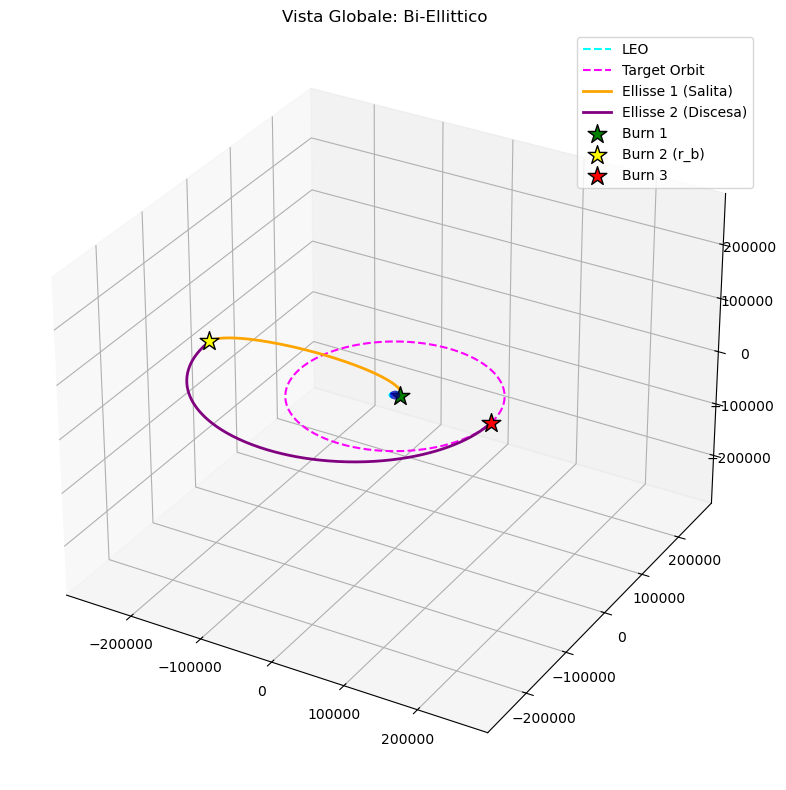

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import orekit
from orekit.pyhelpers import setup_orekit_curdir
from org.orekit.utils import Constants

# ==========================================
# 1. INIZIALIZZAZIONE AMBIENTE OREKIT
# ==========================================
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main')

# ==========================================
# 2. COSTANTI FISICHE (Da Orekit, in km)
# ==========================================
mu_E = Constants.WGS84_EARTH_MU / 1e9             # Parametro gravitazionale Terrestre [km^3/s^2]
R_E = Constants.WGS84_EARTH_EQUATORIAL_RADIUS / 1000.0  # Raggio medio terrestre [km]

# ==========================================
# 3. DATI DELLE ORBITE DI PARCHEGGIO E MANOVRA
# ==========================================
# Orbita Iniziale (LEO)
h1 = 300.0                     # Quota LEO [km]
r1 = R_E + h1                  # Raggio LEO [km]
v1 = np.sqrt(mu_E / r1)        # Velocità circolare LEO [km/s]

# Orbita Finale (Super-GEO per giustificare il bi-ellittico)
# Usiamo un raggio finale r2 = 20 * r1 per rendere il bi-ellittico conveniente rispetto a Hohmann
r2 = 20.0 * r1                 
h2 = r2 - R_E
v2 = np.sqrt(mu_E / r2)        # Velocità circolare Finale [km/s]

# Raggio intermedio di manovra (Apogeo remoto, r_b)
r_b = 40.0 * r1                # Lo spingiamo molto lontano per massimizzare l'efficienza

print("========================================================")
print("  1. PARAMETRI DELLE ORBITE")
print("========================================================")
print(f"Raggio LEO (r1): {r1:.2f} km | Velocita': {v1:.4f} km/s")
print(f"Raggio Target (r2): {r2:.2f} km | Velocita': {v2:.4f} km/s")
print(f"Raggio Remoto (r_b): {r_b:.2f} km\n")

# ==========================================
# 4. CALCOLO TRASFERIMENTO BI-ELLITTICO (3 Impulsi)
# ==========================================
# --- Ellisse 1: Da r1 (perigeo) a r_b (apogeo) ---
a_tx1 = (r1 + r_b) / 2.0
v_tx1_perigeo = np.sqrt(mu_E * (2/r1 - 1/a_tx1))
v_tx1_apogeo = np.sqrt(mu_E * (2/r_b - 1/a_tx1))

# --- Ellisse 2: Da r_b (apogeo) a r2 (perigeo) ---
a_tx2 = (r_b + r2) / 2.0
v_tx2_apogeo = np.sqrt(mu_E * (2/r_b - 1/a_tx2))
v_tx2_perigeo = np.sqrt(mu_E * (2/r2 - 1/a_tx2))

# --- Calcolo dei Delta-V ---
DeltaV_1 = v_tx1_perigeo - v1               # Accelerazione al perigeo (Burn 1)
DeltaV_2 = v_tx2_apogeo - v_tx1_apogeo      # Accelerazione all'apogeo remoto (Burn 2)
DeltaV_3 = v_tx2_perigeo - v2               # Frenata al nuovo perigeo target (Burn 3)

DeltaV_Tot_BiElliptic = DeltaV_1 + DeltaV_2 + DeltaV_3

# Tempi di volo (Mezzo periodo per ogni ellisse)
TOF1_sec = np.pi * np.sqrt((a_tx1**3) / mu_E)
TOF2_sec = np.pi * np.sqrt((a_tx2**3) / mu_E)
TOF_Tot_days = (TOF1_sec + TOF2_sec) / 86400.0

print("========================================================")
print("  2. RISULTATI TRASFERIMENTO BI-ELLITTICO")
print("========================================================")
print(f"Tempo di Volo Ellisse 1: {TOF1_sec/86400.0:.2f} giorni")
print(f"Tempo di Volo Ellisse 2: {TOF2_sec/86400.0:.2f} giorni")
print(f"Tempo di Volo Totale:    {TOF_Tot_days:.2f} giorni\n")

print("========================================================")
print("  3. BUDGET DELTA-V TOTALE")
print("========================================================")
print(f"Delta V 1 (Partenza LEO):      {DeltaV_1:.4f} km/s")
print(f"Delta V 2 (Apogeo remoto r_b): {DeltaV_2:.4f} km/s")
print(f"Delta V 3 (Frenata r2):        {DeltaV_3:.4f} km/s")
print(f"DELTA V TOTALE:                {DeltaV_Tot_BiElliptic:.4f} km/s")
print("========================================================")

# ==========================================
# 5. VISUALIZZAZIONE 3D (DUAL VIEW: SISTEMA E ZOOM LEO)
# ==========================================
fig = plt.figure(figsize=(18, 8))

# Array angolari
u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
theta_orb = np.linspace(0, 2*np.pi, 200)

# Orbite Circolari
x_leo = r1 * np.cos(theta_orb); y_leo = r1 * np.sin(theta_orb)
x_target = r2 * np.cos(theta_orb); y_target = r2 * np.sin(theta_orb)

# Ellisse 1 (Mezzo giro: da 0 a pi)
theta_tx1 = np.linspace(0, np.pi, 200)
ecc1 = (r_b - r1) / (r_b + r1)
r_plot1 = (a_tx1 * (1 - ecc1**2)) / (1 + ecc1 * np.cos(theta_tx1))
x_tx1 = r_plot1 * np.cos(theta_tx1)
y_tx1 = r_plot1 * np.sin(theta_tx1)

# Ellisse 2 (Mezzo giro: da pi a 2*pi, per tornare giù)
theta_tx2 = np.linspace(np.pi, 2*np.pi, 200)
ecc2 = (r_b - r2) / (r_b + r2)
# Nota: l'equazione polare è rispetto al perigeo (che è r2). Quindi l'angolo dell'apogeo r_b per l'ellisse 2 è pi.
# Per mappare correttamente, usiamo (theta_tx2 - pi) in modo che a pi dia l'apogeo e a 2*pi dia il perigeo r2.
r_plot2 = (a_tx2 * (1 - ecc2**2)) / (1 + ecc2 * np.cos(theta_tx2 - np.pi))
# Per mantenere la geometria in cui l'apogeo r_b è sull'asse X negativo (come alla fine dell'ellisse 1):
# L'apogeo di ellisse 1 è a theta=pi. Vogliamo che l'ellisse 2 parta da lì e arrivi a theta=2*pi.
# Modifichiamo l'angolo di plot per far combaciare l'apogeo:
r_plot2_geom = (a_tx2 * (1 - ecc2**2)) / (1 + ecc2 * np.cos(theta_tx2)) # L'apogeo è a theta=pi, ok.
x_tx2 = r_plot2_geom * np.cos(theta_tx2)
y_tx2 = r_plot2_geom * np.sin(theta_tx2)

# Coordinate 3D nulle
z_zeros = np.zeros(200)

# ---------------------------------------------------------
# SUBPLOT 1: VISTA GLOBALE (Scala su r_b)
# ---------------------------------------------------------
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(R_E * np.cos(u) * np.sin(v), R_E * np.sin(u) * np.sin(v), R_E * np.cos(v), color='blue', alpha=0.6)

ax1.plot(x_leo, y_leo, z_zeros, color='cyan', linestyle='--', label='LEO')
ax1.plot(x_target, y_target, z_zeros, color='magenta', linestyle='--', label='Target Orbit')

ax1.plot(x_tx1, y_tx1, z_zeros, label='Ellisse 1 (Salita)', color='orange', linewidth=2)
ax1.plot(x_tx2, y_tx2, z_zeros, label='Ellisse 2 (Discesa)', color='purple', linewidth=2)

ax1.scatter([x_tx1[0]], [y_tx1[0]], [0], color='green', s=200, marker='*', edgecolor='black', label='Burn 1')
ax1.scatter([x_tx1[-1]], [y_tx1[-1]], [0], color='yellow', s=200, marker='*', edgecolor='black', label='Burn 2 (r_b)')
ax1.scatter([x_tx2[-1]], [y_tx2[-1]], [0], color='red', s=200, marker='*', edgecolor='black', label='Burn 3')

ax1.set_xlim([-r_b*1.1, r_b*1.1]); ax1.set_ylim([-r_b*1.1, r_b*1.1]); ax1.set_zlim([-r_b*1.1, r_b*1.1])
ax1.set_title('Vista Globale: Bi-Ellittico')
ax1.legend()

fig.tight_layout()
fig.savefig('bielliptic_transfer_plot.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()